# APGGS Evaluation / Ablation Study

This notebook uses the original APGGS implementation in `ADAPTIVE_PROBEGENETICALGORITHM.ipynb` as the source of truth. It adds a reproducible evaluation layer that: 
- runs the full APGGS baseline;
- detects the dataset-specific reference generation;
- evaluates each ablation under the same generation budget;
- saves CSV/Excel summaries and convergence plots.

In [31]:
import ast
import json
import os
import random
import time
from collections import Counter, defaultdict, deque
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tsplib95

try:
    import elkai
    HAS_ELKAI = True
except Exception:
    elkai = None
    HAS_ELKAI = False

SOURCE_NOTEBOOK = Path('ADAPTIVE_PROBEGENETICALGORITHM.ipynb')
assert SOURCE_NOTEBOOK.exists(), 'The original APGGS notebook must be in the same workspace.'

def load_source_api(path: Path):
    notebook = json.loads(path.read_text(encoding='utf-8'))
    source_namespace = dict(globals())
    source_namespace['HAS_ELKAI'] = HAS_ELKAI
    source_namespace['elkai'] = elkai
    allowed_assignments = {'TSPLIB_BEST_KNOWN', 'CONFIG'}

    for cell in notebook.get('cells', []):
        raw_source = ''.join(cell.get('source', []))
        source = ''.join(line for line in raw_source.splitlines(True) if not line.lstrip().startswith('!'))
        if not source.strip():
            continue
        tree = ast.parse(source, filename=str(path))
        selected = []
        for node in tree.body:
            if isinstance(node, ast.ImportFrom) and node.module == 'google.colab':
                continue
            if isinstance(node, ast.Import) and any(alias.name.startswith('google.colab') for alias in node.names):
                continue
            if isinstance(node, (ast.Import, ast.ImportFrom, ast.ClassDef, ast.FunctionDef, ast.AsyncFunctionDef)):
                selected.append(node)
            elif isinstance(node, (ast.Assign, ast.AnnAssign)):
                targets = []
                if isinstance(node, ast.Assign):
                    targets = [target.id for target in node.targets if isinstance(target, ast.Name)]
                elif isinstance(node.target, ast.Name):
                    targets = [node.target.id]
                if any(name in allowed_assignments for name in targets):
                    selected.append(node)
        if not selected:
            continue
        module = ast.Module(body=selected, type_ignores=[])
        ast.fix_missing_locations(module)
        exec(compile(module, str(path), 'exec'), source_namespace, source_namespace)

    required = [
        'TSPInstance', 'load_tsplib_instance', 'GAConfig', 'build_knn_lists',
        'generate_initial_population', 'create_individual', 'run_adaptive_ga',
        'PredictiveMemoryGraph', 'AdaptiveOperatorSelector', 'StagnationDetector',
    ]
    missing = [name for name in required if name not in source_namespace]
    if missing:
        raise RuntimeError(f'Source API is incomplete. Missing: {missing}')
    return source_namespace

api = load_source_api(SOURCE_NOTEBOOK)
globals().update(api)
print('Loaded APGGS definitions from', SOURCE_NOTEBOOK.name)

Loaded APGGS definitions from ADAPTIVE_PROBEGENETICALGORITHM.ipynb


In [32]:
# ============================================================
# INPUT CONFIGURATION — LOCAL TSPLIB DATASET
# ============================================================
# Run this block after the source setup block. A Windows file picker
# opens automatically so you can select any local .tsp or .atsp file.

DATASET_PATH = Path('data/your_dataset.tsp')
USE_FILE_DIALOG = True
SEEDS = [42]

@dataclass
class AblationConfig:
    use_probe: bool = True
    use_pmg: bool = True
    use_double_bridge: bool = True
    use_selective_lkh: bool = True
    use_adaptive_control: bool = True
    basic_ga: bool = False

def select_local_dataset():
    if USE_FILE_DIALOG:
        import tkinter as tk
        from tkinter import filedialog
        root = tk.Tk()
        root.withdraw()
        root.attributes('-topmost', True)
        selected = filedialog.askopenfilename(
            title='Select your TSPLIB dataset',
            filetypes=[('TSPLIB datasets', '*.tsp *.atsp'), ('All files', '*.*')],
        )
        root.destroy()
        if not selected:
            raise FileNotFoundError('No dataset was selected.')
        return Path(selected)
    path = Path(DATASET_PATH).expanduser()
    if not path.exists():
        raise FileNotFoundError(f'Dataset not found: {path}')
    return path

def load_local_instance(path):
    path = Path(path)
    if path.suffix.lower() not in {'.tsp', '.atsp'}:
        raise ValueError('Please select a .tsp or .atsp TSPLIB file.')
    instance = api['load_tsplib_instance'](str(path))
    dataset_name = str(instance.name or path.stem).lower()
    print(f'File selected: {path.resolve()}')
    print(f'Dataset: {dataset_name}')
    print(f'Cities: {instance.n}')
    print(f'TSPLIB best known: {api["best_known"](dataset_name)}')
    return dataset_name, instance

def standard_population(instance, seed):
    rng = random.Random(seed)
    config = api['GAConfig'](seed=seed)
    neighbors = api['build_knn_lists'](instance.dist, config.k_neighbors)
    seed_tour = api['nearest_neighbor_tour'](instance.dist, start=0)
    optimized_seed, _ = api['two_opt'](
        seed_tour,
        instance.dist,
        neighbors,
        max_passes=2,
    )
    population = api['generate_initial_population'](
        instance,
        optimized_seed,
        config,
        rng,
    )
    return population, neighbors

def variant_name(config: AblationConfig):
    if config.basic_ga:
        return 'Basic GA'
    if not config.use_pmg:
        return 'Without PMG'
    if not config.use_double_bridge:
        return 'Without Double Bridge'
    if not config.use_adaptive_control:
        return 'Without Adaptive Control'
    return 'Full APGGS'

ABLATION_CONFIGS = {
    'Full APGGS': AblationConfig(),
    'Without PMG': AblationConfig(use_pmg=False, use_selective_lkh=False),
    'Without Double Bridge': AblationConfig(use_double_bridge=False, use_selective_lkh=False),
    'Without Adaptive Control': AblationConfig(use_adaptive_control=False, use_selective_lkh=False),
    'Basic GA': AblationConfig(use_probe=False, use_pmg=False, use_double_bridge=False, use_selective_lkh=False, use_adaptive_control=False, basic_ga=True),
}

selected_dataset_path = select_local_dataset()
dataset_name, dataset_instance = load_local_instance(selected_dataset_path)
print('Dataset selection complete. Run the final block to start APGGS evaluation.')

File selected: C:\Users\VICTUS\Downloads\a280.tsp
Dataset: a280
Cities: 280
TSPLIB best known: 2579
Dataset selection complete. Run the final block to start APGGS evaluation.


In [33]:
# Shared alias used by the evaluation runner.
source = api

In [34]:
def run_variant(instance, config: AblationConfig, seed: int, max_generations: int):
    source = api
    cfg = source['GAConfig'](seed=seed)
    cfg.max_generations = int(max_generations)
    if not config.use_selective_lkh:
        cfg.lkh_cadence = max_generations + 1

    population, neighbors = standard_population(instance, seed)
    original = {
        'AdaptiveOperatorSelector': source['AdaptiveOperatorSelector'],
        'PredictiveMemoryGraph': source['PredictiveMemoryGraph'],
        'stagnation_observe': source['StagnationDetector'].observe,
    }

    try:
        if not config.use_adaptive_control:
            class FixedSelector:
                def __init__(self, rng):
                    self.plays = {'weak_edge_surgery': 0, 'predictive_or_opt': 0, 'two_opt': 0}
                def select(self):
                    return 'two_opt'
                def update(self, operator, relative_gain):
                    pass
            source['AdaptiveOperatorSelector'] = FixedSelector

        if not config.use_double_bridge:
            def never_stagnant(self, best_cost, diversity):
                return False
            source['StagnationDetector'].observe = never_stagnant

        if not config.use_pmg or not config.use_probe:
            base_pmg = original['PredictiveMemoryGraph']
            use_memory = config.use_pmg
            use_probe = config.use_probe
            class AblatedPredictiveMemoryGraph(base_pmg):
                def update(self, population):
                    if use_memory:
                        return super().update(population)
                def edge_quality(self, a, b):
                    return super().edge_quality(a, b) if use_memory else 0.0
                def predicted_successors(self, city, k=5):
                    return super().predicted_successors(city, k) if use_memory and use_probe else []
                def elite_segments(self, top_k=30):
                    return super().elite_segments(top_k) if use_memory else []
            source['PredictiveMemoryGraph'] = AblatedPredictiveMemoryGraph

        if config.basic_ga:
            cfg.mutation_rate = 0.15
            cfg.offspring_local_search_probability = 0.15
            cfg.adaptive_elite_count = 0
            cfg.memory_elite_fraction = 0.0

        start = time.time()
        result = source['run_adaptive_ga'](instance, population, neighbors, cfg)
        result['runtime'] = time.time() - start
        result['variant'] = variant_name(config)
        result['seed'] = seed
        result['max_generations'] = int(max_generations)
        assert result['generations'] <= max_generations
        return result
    finally:
        source['AdaptiveOperatorSelector'] = original['AdaptiveOperatorSelector']
        source['PredictiveMemoryGraph'] = original['PredictiveMemoryGraph']
        source['StagnationDetector'].observe = original['stagnation_observe']

def summarize_variant(dataset, variant_label, seed, result, reference_generation, best_known_value):
    best_cost = float(result['best_cost'])
    return {
        'Dataset': dataset,
        'Variant': variant_label,
        'Seed': seed,
        'Reference Generation': reference_generation,
        'Actual Generations Executed': int(result['generations']),
        'Best Tour Length': best_cost,
        'Best Generation': int(result['best_generation']),
        'Runtime': float(result['runtime']),
        'TSPLIB Best Known': best_known_value,
        'Absolute Error': best_cost - best_known_value if best_known_value is not None else np.nan,
        'Gap (%)': ((best_cost - best_known_value) / best_known_value) * 100.0 if best_known_value is not None else np.nan,
        'Final Tour': result['best_tour'],
        'History': result['history'],
    }

def print_experiment_header(dataset, variant_label, seed, reference_generation):
    print('=' * 72)
    print(f'Dataset: {dataset.upper()} | Variant: {variant_label} | Seed: {seed}')
    print(f'Reference Generation: {reference_generation}')
    print(f'Maximum Allowed Generations: {reference_generation}')
    print('=' * 72)

def save_experiment_outputs(results_df, plots_dir, results_dir):
    results_dir.mkdir(parents=True, exist_ok=True)
    plots_dir.mkdir(parents=True, exist_ok=True)
    export_df = results_df.drop(columns=['History', 'Final Tour'], errors='ignore')
    export_df.to_csv(results_dir / 'apggs_ablation_results.csv', index=False)
    export_df.to_excel(results_dir / 'apggs_ablation_results.xlsx', index=False)
    summary = results_df.groupby(['Dataset', 'Variant'], as_index=False).agg({
        'Best Tour Length': ['mean', 'min', 'max', 'std'],
        'Runtime': ['mean', 'min', 'max'],
        'Gap (%)': ['mean', 'min', 'max'],
    })
    summary.columns = ['Dataset', 'Variant', 'Best Mean', 'Best Min', 'Best Max', 'Best Std', 'Runtime Mean', 'Runtime Min', 'Runtime Max', 'Gap Mean', 'Gap Min', 'Gap Max']
    summary.to_csv(results_dir / 'apggs_summary.csv', index=False)
    return summary

def make_convergence_plot(history_by_variant, dataset_name):
    Path('evaluation/plots').mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(12, 7))
    for name, history in history_by_variant.items():
        plt.plot(range(len(history)), history, linewidth=2, label=name)
    plt.xlabel('Generation')
    plt.ylabel('Best-so-far tour length')
    plt.title(f'APGGS convergence comparison - {dataset_name}')
    plt.grid(alpha=0.25)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.savefig(Path('evaluation/plots') / f'apggs_convergence_{dataset_name}.png', dpi=200)
    plt.show()

def run_ablation_study(dataset_name: str, seeds=None, instance=None):
    seeds = list(seeds or SEEDS)
    instance = instance or load_instance(dataset_name)
    best_known_value = source['best_known'](dataset_name)
    records = []

    for seed in seeds:
        population, neighbors = standard_population(instance, seed)
        cfg = source['GAConfig'](seed=seed)
        cfg.max_generations = 300
        start = time.time()
        full_result = source['run_adaptive_ga'](instance, population, neighbors, cfg)
        full_result['runtime'] = time.time() - start
        reference_generation = int(full_result['best_generation'])
        print_experiment_header(dataset_name, 'Full APGGS', seed, reference_generation)
        records.append(summarize_variant(dataset_name, 'Full APGGS', seed, full_result, reference_generation, best_known_value))

        for variant_label, variant_cfg in ABLATION_CONFIGS.items():
            if variant_label == 'Full APGGS':
                continue
            result = run_variant(instance, variant_cfg, seed, reference_generation)
            assert result['generations'] <= reference_generation
            print_experiment_header(dataset_name, variant_label, seed, reference_generation)
            records.append(summarize_variant(dataset_name, variant_label, seed, result, reference_generation, best_known_value))

    df = pd.DataFrame(records)
    save_experiment_outputs(df, Path('evaluation/plots'), Path('evaluation/results'))
    histories = {row['Variant']: row['History'] for _, row in df.iterrows()}
    make_convergence_plot(histories, dataset_name)
    print('APGGS EVALUATION COMPLETE')
    print(df[['Variant', 'Best Tour Length', 'Best Generation', 'Runtime', 'Gap (%)']].to_string(index=False))
    return df

print('Evaluation runner ready.')

Evaluation runner ready.


In [35]:
def make_convergence_plot(history_by_variant, dataset_name):
    Path('evaluation/plots').mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(12, 7))
    ordered_variants = [
        name for name in history_by_variant if name != 'Full APGGS'
    ]
    if 'Full APGGS' in history_by_variant:
        ordered_variants.append('Full APGGS')
    for name in ordered_variants:
        line_style = {
            'color': 'blue',
            'linewidth': 2.8,
            'zorder': 3,
        } if name == 'Full APGGS' else {
            'linewidth': 2,
            'zorder': 2,
        }
        plt.plot(
            range(len(history_by_variant[name])),
            history_by_variant[name],
            label=name,
            **line_style,
        )
    plt.xlabel('Generation')
    plt.ylabel('Best-so-far tour length')
    plt.title(f'APGGS convergence comparison - {dataset_name}')
    plt.grid(alpha=0.25)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.savefig(Path('evaluation/plots') / f'apggs_convergence_{dataset_name}.png', dpi=200)
    plt.show()


OUTPUT BLOCK 2 — GENETIC POPULATION / EVOLUTION

####################################################################################################
STARTING GENERATION 1
####################################################################################################

GENERATION 1 — EVOLVED POPULATION

ID=01 | Generation=001
Method  : Elite
Cost    : 2,975.00
Fitness : 0.000336134454
Route   : 178-179-180-175-176-150-151-155-152-154-153-128-127-20-19-18-17-16-132-131-130-129-126-125-124-29-30-31-28-27-26-25-21-24-22-23-13-12-11-10-9-7-6-8-274-273-272-271-270-15-14-269-133-134-135-136-137-138-139-140-141-142-143-144-145-146-147-148-149-177-157-156-118-119-120-121-122-123-32-33-34-35-36-37-38-39-40-41-42-59-60-117-61-62-63-64-65-66-69-70-71-72-73-74-75-76-77-78-79-80-81-82-83-84-85-115-114-113-110-109-107-103-102-101-100-99-98-97-92-93-94-95-96-91-90-89-88-108-111-87-86-112-116-58-43-44-45-46-47-48-49-50-51-52-53-54-55-56-57-67-68-104-105-106-172-173-160-161-162-163-164-165-166-167

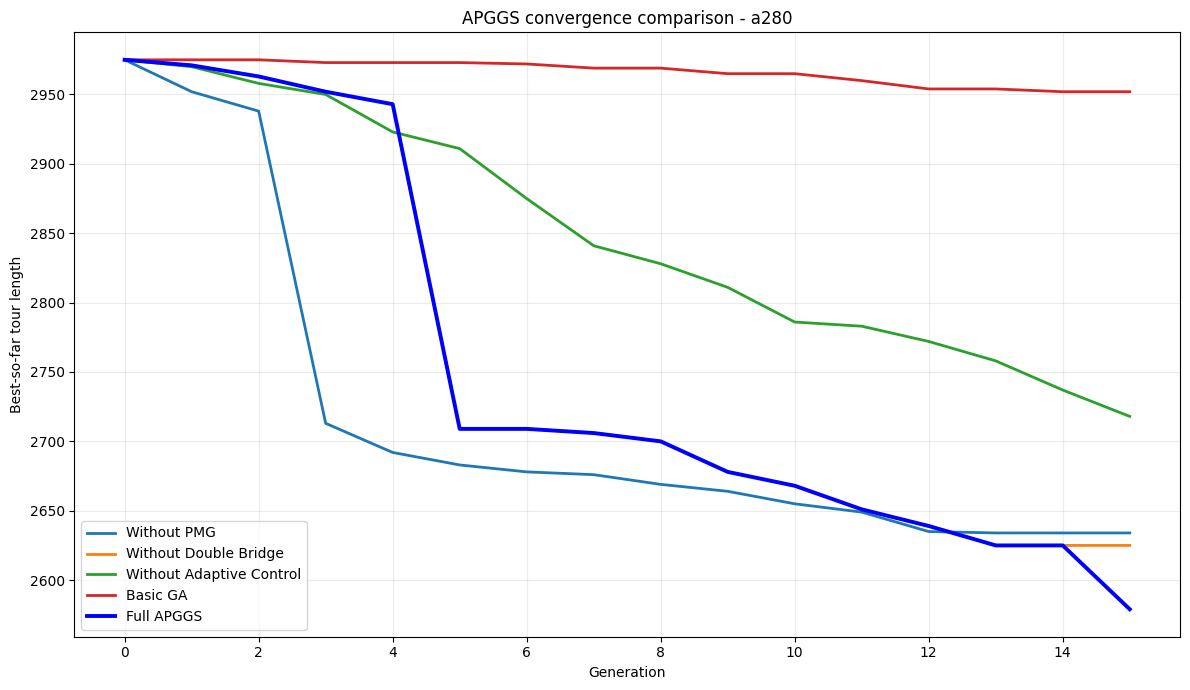

APGGS EVALUATION COMPLETE
                 Variant  Best Tour Length  Best Generation   Runtime   Gap (%)
              Full APGGS            2579.0               15 17.854101  0.000000
             Without PMG            2634.0               13  7.665028  2.132610
   Without Double Bridge            2625.0               13  5.068542  1.783637
Without Adaptive Control            2718.0               15  0.937830  5.389686
                Basic GA            2952.0               14  0.240396 14.462970

Saved outputs:
  evaluation/results/apggs_ablation_results.csv
  evaluation/results/apggs_ablation_results.xlsx
  evaluation/results/apggs_summary.csv
  evaluation/plots/apggs_convergence_a280.png


In [36]:
# ============================================================
# RUN THE COMPLETE APGGS EVALUATION PIPELINE
# ============================================================
# The dataset was selected in the first configuration block.

results = run_ablation_study(
    dataset_name,
    seeds=SEEDS,
    instance=dataset_instance,
)

print('\nSaved outputs:')
print('  evaluation/results/apggs_ablation_results.csv')
print('  evaluation/results/apggs_ablation_results.xlsx')
print('  evaluation/results/apggs_summary.csv')
print(f'  evaluation/plots/apggs_convergence_{dataset_name}.png')